# 📌 Loan Approval Prediction using Machine Learning

## 🧠 Introduction

Loan approval is a critical decision-making process in the banking and financial sector. Financial institutions receive thousands of loan applications and must evaluate each applicant’s eligibility based on financial stability, repayment capacity, and credit history.

Traditional manual evaluation methods can be time-consuming, inconsistent, and prone to human bias. With the advancement of data-driven technologies, Machine Learning provides an efficient and objective solution for automating the loan approval process.

In this project, we develop a supervised machine learning classification model that predicts whether a loan application will be **Approved or Not Approved** based on applicant information such as income, education, employment status, loan amount, and credit history.

The objective is to build an accurate, reliable, and interpretable model that can assist financial institutions in improving decision-making efficiency and consistency.

# 🎯 Problem Statement

The goal of this project is to build a **supervised classification model** that predicts the loan approval status of applicants using historical financial and demographic data.

### 📍 Objective:
To classify loan applications into:
- ✅ Approved
- ❌ Not Approved

### 📊 Target Variable:
`Loan_Status`

### 📌 Type of Machine Learning:
Supervised Learning – Classification

The model will analyze multiple input features such as:
- Applicant Income
- Loan Amount
- Education
- Employment Status
- Credit History
- Property Area

The final model will be evaluated using performance metrics such as:
- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-Score

The outcome of this project aims to demonstrate how machine learning can assist financial institutions in automating loan screening processes while maintaining accuracy and fairness.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [7]:
ld=pd.read_csv('loan_prediction.csv')

In [8]:
ld.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
type(ld)

pandas.core.frame.DataFrame

In [10]:
ld.shape

(614, 13)

In [11]:
ld.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


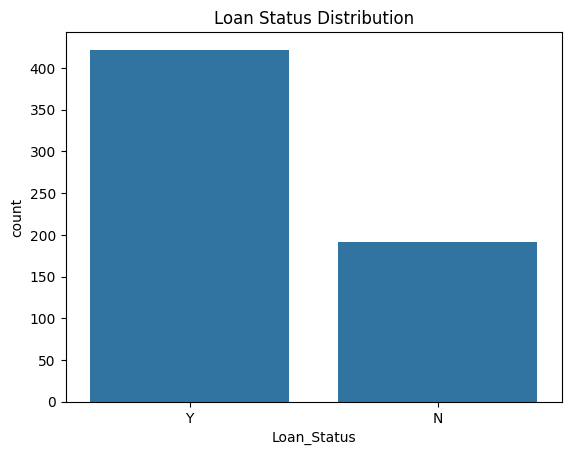

In [12]:
sns.countplot(x='Loan_Status', data=ld)
plt.title("Loan Status Distribution")
plt.show()

In [13]:
ld.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [14]:
# Categorical columns
cat_cols = ['Gender','Married','Dependents','Self_Employed',
            'Loan_Amount_Term','Credit_History']

for col in cat_cols:
    ld[col] = ld[col].fillna(ld[col].mode()[0])

# Numerical column
ld['LoanAmount'] = ld['LoanAmount'].fillna(ld['LoanAmount'].median())

In [15]:
# dropping the missing values

ld. isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [16]:
ld.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True)
ld.replace({"Married":{"No":0,"Yes":1}},inplace=True)
ld.replace({"Gender":{"Female":0,"Male":1}},inplace=True)
ld.replace({"Property_Area":{"Rural":0,"Semiurban":1,"Urban":2}},inplace=True)
ld.replace({"Education":{"Not Graduate":0,"Graduate":1}},inplace=True)





C:\Users\sivan\AppData\Local\Temp\ipykernel_8280\407771242.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ld.replace({"Loan_Status":{"N":0,"Y":1}},inplace=True)
C:\Users\sivan\AppData\Local\Temp\ipykernel_8280\407771242.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ld.replace({"Married":{"No":0,"Yes":1}},inplace=True)
C:\Users\sivan\AppData\Local\Temp\ipykernel_8280\407771242.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicit

In [17]:

ld.replace({"Self_Employed":{"Yes":0,"No":1}},inplace=True)


C:\Users\sivan\AppData\Local\Temp\ipykernel_8280\3996744255.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ld.replace({"Self_Employed":{"Yes":0,"No":1}},inplace=True)


In [18]:
ld.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,1,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,1,1,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,1,0,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,0,1,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,1,1,6000,0.0,141.0,360.0,1.0,2,1


In [19]:
ld["Dependents"].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [20]:
ld=ld.replace(to_replace="3+",value=4)



In [21]:
ld["Dependents"].value_counts()

Dependents
0    360
1    102
2    101
4     51
Name: count, dtype: int64

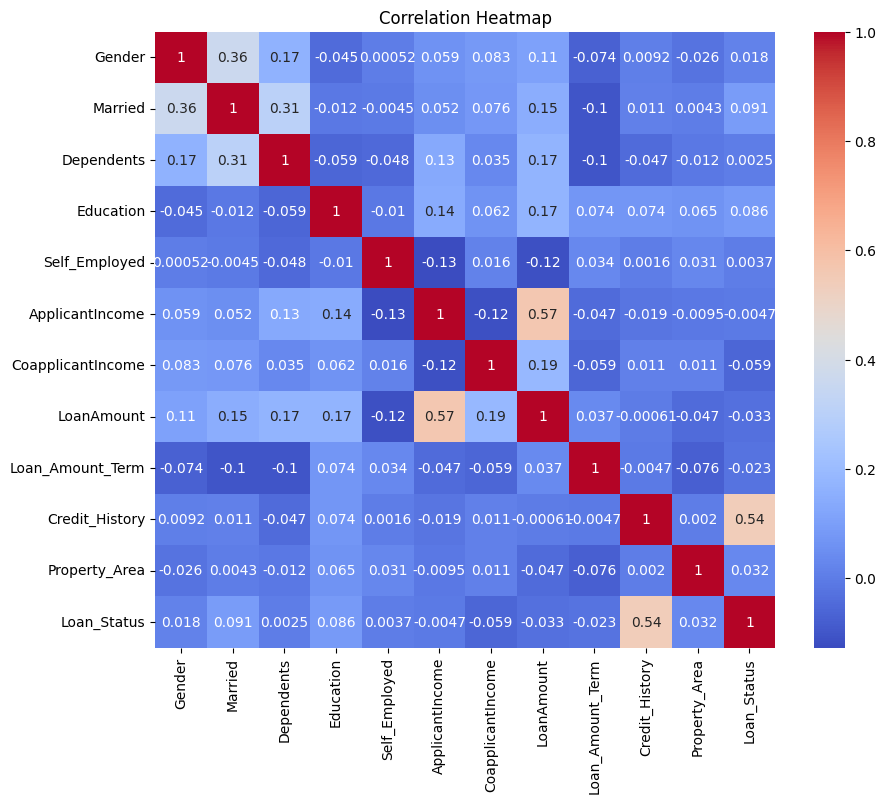

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(ld.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
ld= ld.drop(columns=['Loan_ID'], axis=1)

<Axes: xlabel='Education', ylabel='count'>

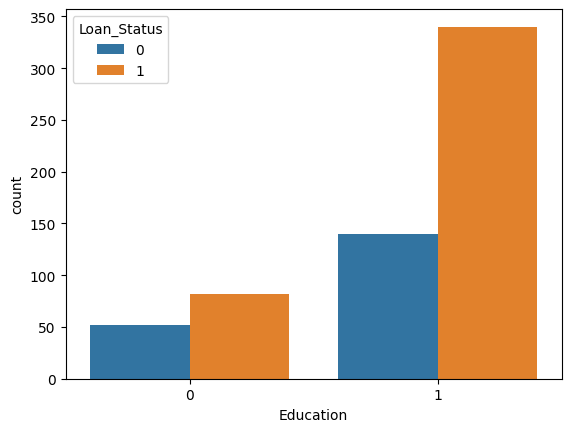

In [26]:
sns.countplot(x="Education",hue="Loan_Status",data=ld)

<Axes: xlabel='Self_Employed', ylabel='count'>

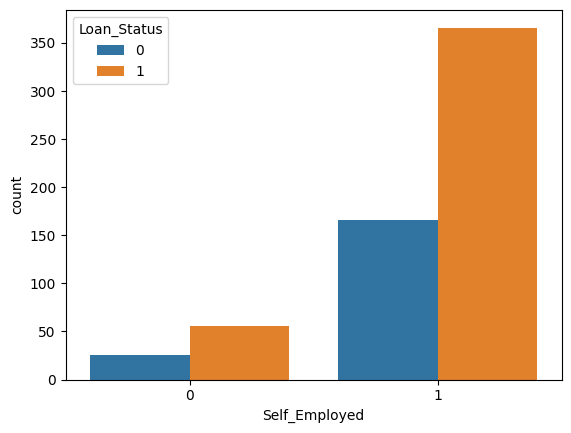

In [28]:
sns.countplot(x="Self_Employed",hue="Loan_Status",data=ld)

<Axes: xlabel='Gender', ylabel='count'>

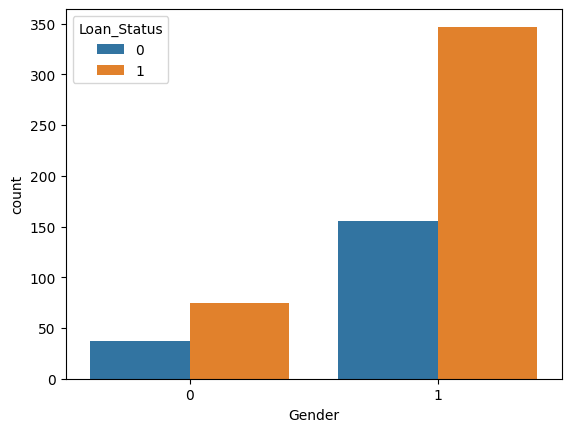

In [27]:
sns.countplot(x="Gender",hue="Loan_Status",data=ld)

In [29]:
x=ld.drop(columns=["Loan_Status"],axis=1)
y=ld["Loan_Status"]

In [30]:
print(x)


     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0          0          1              1             5849   
1         1        1          1          1              1             4583   
2         1        1          0          1              0             3000   
3         1        1          0          0              1             2583   
4         1        0          0          1              1             6000   
..      ...      ...        ...        ...            ...              ...   
609       0        0          0          1              1             2900   
610       1        1          4          1              1             4106   
611       1        1          1          1              1             8072   
612       1        1          2          1              1             7583   
613       0        0          0          1              0             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

In [31]:
print(y)

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 614, dtype: int64


In [32]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,stratify=y,random_state=4)

In [33]:
print(x.shape,x_train.shape,x_test.shape)

(614, 11) (491, 11) (123, 11)


In [34]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [35]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

y_pred_lr = lr.predict(x_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8211382113821138


In [36]:
svm_model = SVC(kernel='linear')
svm_model.fit(x_train, y_train)

y_pred_svm = svm_model.predict(x_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8211382113821138


In [37]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7967479674796748


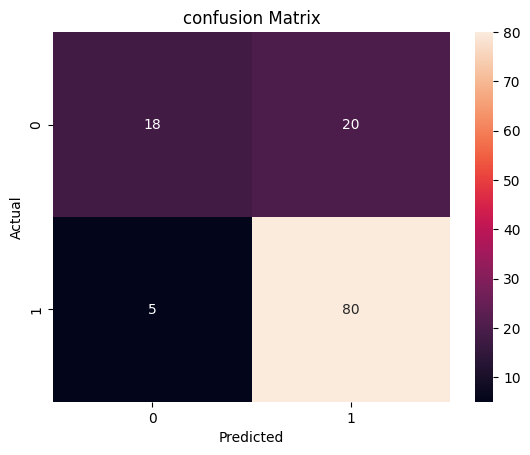

In [38]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion Matrix")
plt.show()

In [39]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.47      0.59        38
           1       0.80      0.94      0.86        85

    accuracy                           0.80       123
   macro avg       0.79      0.71      0.73       123
weighted avg       0.79      0.80      0.78       123



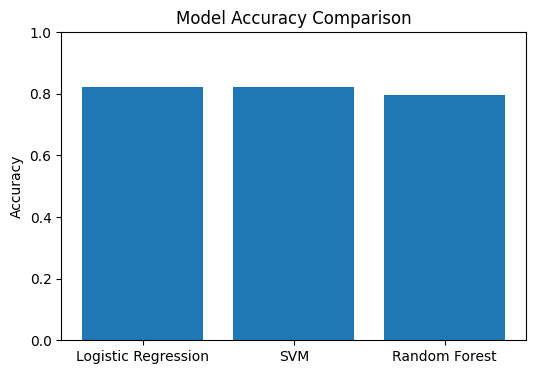

In [40]:
# Store accuracy scores
lr_acc = accuracy_score(y_test, y_pred_lr)
svm_acc = accuracy_score(y_test, y_pred_svm)
rf_acc = accuracy_score(y_test, y_pred_rf)

# Plot comparison
models = ['Logistic Regression','SVM','Random Forest']
accuracy = [lr_acc, svm_acc, rf_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [41]:
print("LR:", lr_acc)
print("SVM:", svm_acc)
print("RF:", rf_acc)

LR: 0.8211382113821138
SVM: 0.8211382113821138
RF: 0.7967479674796748


In [42]:
# Sample Applicant Data
# Format:
# [Gender, Married, Dependents, Education, Self_Employed,
#  ApplicantIncome, CoapplicantIncome, LoanAmount,
#  Loan_Amount_Term, Credit_History, Property_Area]

new_applicant = [[1, 1, 2, 1, 0, 5000, 2000, 150, 360, 1, 2]]

# Apply same scaling
new_applicant_scaled = scaler.transform(new_applicant)

# Predict
prediction = lr.predict(new_applicant_scaled)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

Loan Approved


c:\Users\sivan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# 🏁 Conclusion

In this project, we successfully developed a Machine Learning-based loan approval prediction system using classification techniques.

The dataset was thoroughly preprocessed through handling missing values, encoding categorical variables, feature scaling, and stratified train-test splitting to ensure balanced evaluation.

Three classification models were implemented and compared:

- Logistic Regression  
- Support Vector Machine (SVM)  
- Random Forest Classifier  

Among the models tested, **Logistic Regression and SVM achieved the highest accuracy of 82.11%**, indicating that the dataset is nearly linearly separable. Random Forest showed comparable performance but did not significantly improve accuracy.

The analysis revealed that **Credit History is the most influential feature** in determining loan approval status.

Overall, this project demonstrates how machine learning can effectively assist financial institutions in automating loan screening processes, improving efficiency, consistency, and decision-making reliability.

This system can be further enhanced through hyperparameter tuning, cross-validation, and deployment as a real-time predictive application.